<a href="https://colab.research.google.com/github/SZ330/EE344-Stock-Market-Predictor/blob/main/SPY_Predictors_nine_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPY Predictors for 1995 - 2025
This notebook builds and evaluates a machine learning model to predict whether the SPY ETF will go up or down the next trading day based on historical market data. It begins by loading a feature-engineered dataset spanning 1995–2025, removes neutral (no-change) days, and selects a set of technical and calendar-based predictors such as lagged returns, rolling volatility, moving-average ratios, momentum, and volume features. The data is split chronologically into a training period (1995-2010) and a testing period (2010-2025) to preserve the time-series structure and prevent leakage. Three classification models: Logistic Regression, Linear SVM, and Random Forest, are trained (with appropriate scaling for linear models) and evaluated using accuracy, precision, recall, and F1-score. The overall goal of the notebook is to compare these models and determine whether historical price and volume patterns contain predictive signal for next-day market direction, while assessing generalization performance on truly out-of-sample future data.

#### Step 1: Import libraries


In [1]:
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore', category=ConvergenceWarning)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42


#### Step 2: Load data


In [2]:
# Read the nine-feature SPY dataset
SPY_CSV_PATH = 'SPY_1995_2025_nine_features.csv'
df = pd.read_csv(SPY_CSV_PATH)

# Horizon/target configuration
HORIZON_DAYS = 1
TARGET_COL = f'y_{HORIZON_DAYS}d_dir'
RET_EVAL_COL = f'ret_{HORIZON_DAYS}d_fwd'  # evaluation-only; never a model input

# Basic hygiene
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

# Keep strictly binary labels
df = df[df[TARGET_COL].isin([-1.0, 1.0])].copy()

print(df[['Date', TARGET_COL, RET_EVAL_COL]].head())
print(df[['Date', TARGET_COL, RET_EVAL_COL]].tail())
print('shape:', df.shape)
print('label distribution:')
print(df[TARGET_COL].value_counts().sort_index())


        Date  y_1d_dir  ret_1d_fwd
0 1995-03-14      -1.0   -0.001892
1 1995-03-15       1.0    0.006000
2 1995-03-16       1.0    0.000994
3 1995-03-20      -1.0   -0.002522
4 1995-03-21       1.0    0.000948
           Date  y_1d_dir  ret_1d_fwd
7709 2025-12-22       1.0    0.004570
7710 2025-12-23       1.0    0.003518
7711 2025-12-24      -1.0   -0.000101
7712 2025-12-26      -1.0   -0.003564
7713 2025-12-29      -1.0   -0.001221
shape: (7714, 17)
label distribution:
y_1d_dir
-1.0    3504
 1.0    4210
Name: count, dtype: int64


#### Step 3: Feature audit


In [3]:
# Main nine-feature daily input set
BASE_SPY_FEATURE_COLS = [
    'rsi_14',
    'sma_50',
    'adx_20',
    'volume',
    'corr_24',
    'prev_open_close',
    'prev_close_high',
    'prev_close_low',
    'momentum_20',
]

FEATURE_COLS = [c for c in BASE_SPY_FEATURE_COLS if c in df.columns]
CAT_COLS = []

missing = sorted(set(BASE_SPY_FEATURE_COLS) - set(FEATURE_COLS))
assert not missing, f'Missing expected SPY features: {missing}'
assert FEATURE_COLS == BASE_SPY_FEATURE_COLS, 'The main feature set no longer matches the intended nine daily features'
assert TARGET_COL in df.columns, f'Missing target column: {TARGET_COL}'
assert RET_EVAL_COL in df.columns, f'Missing evaluation column: {RET_EVAL_COL}'
assert TARGET_COL not in FEATURE_COLS, 'Leakage: target found in features'
assert RET_EVAL_COL not in FEATURE_COLS, 'Leakage: forward return found in features'

print('Main feature set audit:')
print('Feature names:', FEATURE_COLS)
print('Number of features:', len(FEATURE_COLS))
print('Using intended daily-feature set:', FEATURE_COLS == BASE_SPY_FEATURE_COLS)


Main feature set audit:
Feature names: ['rsi_14', 'sma_50', 'adx_20', 'volume', 'corr_24', 'prev_open_close', 'prev_close_high', 'prev_close_low', 'momentum_20']
Number of features: 9
Using intended daily-feature set: True


#### Step 4: Existing split audit


In [4]:
TRAIN_END = pd.to_datetime('2007-09-30')
VAL_END = pd.to_datetime('2014-12-31')


def build_scenario(df_src, feature_cols, name):
    d = df_src.copy()
    d = d.dropna(subset=feature_cols + [TARGET_COL, RET_EVAL_COL]).copy()

    train_df = d[d['Date'] < TRAIN_END].copy()
    val_df = d[(d['Date'] >= TRAIN_END) & (d['Date'] < VAL_END)].copy()
    test_df = d[d['Date'] >= VAL_END].copy()

    assert len(train_df) > 0, f'{name}: Train split is empty'
    assert len(val_df) > 0, f'{name}: Val split is empty'
    assert len(test_df) > 0, f'{name}: Test split is empty'

    return {
        'name': name,
        'feature_cols': feature_cols,
        'df': d,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'X_train': train_df[feature_cols],
        'y_train': train_df[TARGET_COL],
        'X_val': val_df[feature_cols],
        'y_val': val_df[TARGET_COL],
        'X_test': test_df[feature_cols],
        'y_test': test_df[TARGET_COL],
        'ret_train': train_df[RET_EVAL_COL],
        'ret_val': val_df[RET_EVAL_COL],
        'ret_test': test_df[RET_EVAL_COL],
    }


SPY_SCENARIO = build_scenario(df, FEATURE_COLS, 'SPY only')
SCENARIOS = {'SPY only': SPY_SCENARIO}
ACTIVE_SCENARIO = 'SPY only'

X_train = SPY_SCENARIO['X_train']
y_train = SPY_SCENARIO['y_train']
X_val = SPY_SCENARIO['X_val']
y_val = SPY_SCENARIO['y_val']
X_test = SPY_SCENARIO['X_test']
y_test = SPY_SCENARIO['y_test']
train_df = SPY_SCENARIO['train_df']
val_df = SPY_SCENARIO['val_df']
test_df = SPY_SCENARIO['test_df']

print('Active main scenario:', ACTIVE_SCENARIO)
print('Split logic audit (chronological, unchanged):')
print('TRAIN: Date <', TRAIN_END.date())
print('VAL:   Date >=', TRAIN_END.date(), 'and Date <', VAL_END.date())
print('TEST:  Date >=', VAL_END.date())
print()
print('FULL RANGE:', SPY_SCENARIO['df']['Date'].min(), 'to', SPY_SCENARIO['df']['Date'].max(), f"({len(SPY_SCENARIO['df']):,})")
print('TRAIN:', train_df['Date'].min(), 'to', train_df['Date'].max(), f"({len(train_df):,})")
print('VAL:  ', val_df['Date'].min(), 'to', val_df['Date'].max(), f"({len(val_df):,})")
print('TEST: ', test_df['Date'].min(), 'to', test_df['Date'].max(), f"({len(test_df):,})")
print('Num main-path features:', len(SPY_SCENARIO['feature_cols']))


Active main scenario: SPY only
Split logic audit (chronological, unchanged):
TRAIN: Date < 2007-09-30
VAL:   Date >= 2007-09-30 and Date < 2014-12-31
TEST:  Date >= 2014-12-31

FULL RANGE: 1995-03-14 00:00:00 to 2025-12-29 00:00:00 (7,714)
TRAIN: 1995-03-14 00:00:00 to 2007-09-28 00:00:00 (3,136)
VAL:   2007-10-01 00:00:00 to 2014-12-30 00:00:00 (1,819)
TEST:  2014-12-31 00:00:00 to 2025-12-29 00:00:00 (2,759)
Num main-path features: 9


#### Step 5: Reusable evaluation helpers


In [5]:
def extract_positive_class_scores(model, X):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        classes = list(model.classes_)
        pos_idx = classes.index(1.0)
        return proba[:, pos_idx]

    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        if np.ndim(scores) > 1:
            scores = scores[:, 0]
        return scores

    return None



def evaluate_classifier(model, X, y_true):
    y_true_array = pd.Series(y_true).to_numpy()
    y_pred = model.predict(X)
    scores = extract_positive_class_scores(model, X)

    y_true_bin = (y_true_array == 1.0).astype(int)

    roc_auc = np.nan
    if scores is not None and np.unique(y_true_bin).size == 2:
        roc_auc = roc_auc_score(y_true_bin, scores)

    return {
        'accuracy': accuracy_score(y_true_array, y_pred),
        'precision': precision_score(y_true_array, y_pred, pos_label=1.0, zero_division=0),
        'recall': recall_score(y_true_array, y_pred, pos_label=1.0, zero_division=0),
        'f1': f1_score(y_true_array, y_pred, pos_label=1.0, zero_division=0),
        'roc_auc': roc_auc,
        'confusion_matrix': confusion_matrix(y_true_array, y_pred, labels=[-1.0, 1.0]),
        'predictions': y_pred,
        'scores': scores,
    }




def metric_sort_key(metric_dict):
    roc_auc = metric_dict['roc_auc']
    safe_auc = -np.inf if pd.isna(roc_auc) else roc_auc
    return (metric_dict['accuracy'], metric_dict['f1'], safe_auc)


#### Step 6: Model definitions


In [9]:
MODEL_CONFIGS = {
    'Baseline (Most Frequent)': {'strategy': 'most_frequent'},
    'Baseline (Always Up)': {'strategy': 'constant', 'constant': [1.0]},
    'Baseline (Stratified)': {'strategy': 'stratified'},
    'SVM': {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale'},
    'Decision Tree': {'criterion': 'gini', 'min_samples_split': 4},
    'Logistic Regression': {'solver': 'lbfgs', 'max_iter': 100, 'C': 1.0},
    'Naive Bayes': {},
    'KNN': {'n_neighbors': 20, 'metric': 'minkowski'},
    'Random Forest': {'n_estimators': 80, 'criterion': 'gini', 'min_samples_leaf': 4},
}

SCALED_MODELS = {'SVM', 'Logistic Regression', 'Naive Bayes', 'KNN'}



def build_estimator(model_name, params):
    if model_name == 'Baseline (Most Frequent)':
        return DummyClassifier(strategy=params['strategy'])

    if model_name == 'Baseline (Always Up)':
        return DummyClassifier(
            strategy=params['strategy'],
            constant=params['constant']
        )

    if model_name == 'Baseline (Stratified)':
        return DummyClassifier(
            strategy=params['strategy'],
            random_state=RANDOM_STATE
        )

    if model_name == 'SVM':
        return SVC(
            C=params['C'],
            kernel=params['kernel'],
            degree=params.get('degree', 3),
            gamma=params['gamma'],
        )

    if model_name == 'Decision Tree':
        return DecisionTreeClassifier(
            criterion=params['criterion'],
            min_samples_split=params['min_samples_split'],
            max_depth=params.get('max_depth'),
            random_state=RANDOM_STATE,
        )

    if model_name == 'Logistic Regression':
        return LogisticRegression(
            C=params['C'],
            solver=params['solver'],
            max_iter=params['max_iter'],
        )

    if model_name == 'Naive Bayes':
        return GaussianNB()

    if model_name == 'KNN':
        return KNeighborsClassifier(
            n_neighbors=params['n_neighbors'],
            leaf_size=params.get('leaf_size', 30),
            metric=params['metric'],
        )

    if model_name == 'Random Forest':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            criterion=params['criterion'],
            min_samples_leaf=params['min_samples_leaf'],
            max_depth=params.get('max_depth'),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    raise ValueError(f'Unsupported model: {model_name}')



def build_model_pipeline(model_name, params):
    steps = []

    if model_name in SCALED_MODELS:
        steps.append(('scaler', MinMaxScaler()))

    steps.append(('model', build_estimator(model_name, params)))
    return Pipeline(steps)


model_definition_audit = pd.DataFrame({
    'Model': list(MODEL_CONFIGS.keys()),
    'Fixed Params': [MODEL_CONFIGS[model_name] for model_name in MODEL_CONFIGS],
    'Uses MinMaxScaler': [model_name in SCALED_MODELS for model_name in MODEL_CONFIGS],
})

print('Main comparison is SPY-only and paper-inspired, not a Tesla replication.')
display(model_definition_audit)


Main comparison is SPY-only and paper-inspired, not a Tesla replication.


,Model,Fixed Params,Uses MinMaxScaler
0,Baseline (Most Frequent),{'strategy': 'most_frequent'},False
1,Baseline (Always Up),"{'strategy': 'constant', 'constant': [1.0]}",False
2,Baseline (Stratified),{'strategy': 'stratified'},False
3,SVM,"{'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale'}",True
4,Decision Tree,"{'criterion': 'gini', 'min_samples_split': 4}",False
5,Logistic Regression,"{'solver': 'lbfgs', 'max_iter': 100, 'C': 1.0}",True
6,Naive Bayes,{},True
7,KNN,"{'n_neighbors': 20, 'metric': 'minkowski'}",True
8,Random Forest,"{'n_estimators': 80, 'criterion': 'gini', 'min...",False


#### Rolling Evaluation Setup


In [10]:
rolling_df = SPY_SCENARIO['df'].copy().reset_index(drop=True)

initial_train_mask = rolling_df['Date'] < TRAIN_END
assert initial_train_mask.any(), 'Rolling evaluation requires training data before TRAIN_END'

INITIAL_TRAIN_CUTOFF_IDX = initial_train_mask[initial_train_mask].index.max()
INITIAL_TRAIN_CUTOFF_DATE = rolling_df.loc[INITIAL_TRAIN_CUTOFF_IDX, 'Date']
TEST_START = rolling_df.loc[INITIAL_TRAIN_CUTOFF_IDX + 1, 'Date']
TEST_END = rolling_df['Date'].max()

ROLL_STEP_DAYS = 5
WINDOW_SPECS = {'1D': 1, '3D': 3, '5D': 5}
MAX_WINDOW_DAYS = max(WINDOW_SPECS.values())
WINDOW_DISPLAY_ORDER = ['1D', '3D', '5D']

window_1d_metrics = {model_name: [] for model_name in MODEL_CONFIGS}
window_3d_metrics = {model_name: [] for model_name in MODEL_CONFIGS}
window_5d_metrics = {model_name: [] for model_name in MODEL_CONFIGS}
window_metric_stores = {
    '1D': window_1d_metrics,
    '3D': window_3d_metrics,
    '5D': window_5d_metrics,
}

TOTAL_ROLLING_ITERATIONS = 0
current_cutoff_idx = INITIAL_TRAIN_CUTOFF_IDX

while current_cutoff_idx + MAX_WINDOW_DAYS < len(rolling_df):
    TOTAL_ROLLING_ITERATIONS += 1
    current_cutoff_idx += ROLL_STEP_DAYS

rolling_setup_df = pd.DataFrame({
    'Setting': [
        'Original TRAIN_END parameter',
        'Initial train cutoff in data',
        'TEST_START',
        'TEST_END',
        'Rolling step (trading days)',
        'Total rolling iterations',
    ],
    'Value': [
        TRAIN_END.date(),
        INITIAL_TRAIN_CUTOFF_DATE.date(),
        TEST_START.date(),
        TEST_END.date(),
        ROLL_STEP_DAYS,
        TOTAL_ROLLING_ITERATIONS,
    ],
})

print('Validation split is intentionally unused in the rolling path below.')
print('Forward windows begin immediately after each training cutoff.')
print('Window sizes:', WINDOW_SPECS)
display(rolling_setup_df)


Validation split is intentionally unused in the rolling path below.
Forward windows begin immediately after each training cutoff.
Window sizes: {'1D': 1, '3D': 3, '5D': 5}


,Setting,Value
0,Original TRAIN_END parameter,2007-09-30
1,Initial train cutoff in data,2007-09-28
2,TEST_START,2007-10-01
3,TEST_END,2025-12-29
4,Rolling step (trading days),5
5,Total rolling iterations,915


#### Rolling Training Loop


In [11]:
rolling_metric_rows = []
rolling_iteration_rows = []
current_cutoff_idx = INITIAL_TRAIN_CUTOFF_IDX
iteration_number = 0

while current_cutoff_idx + MAX_WINDOW_DAYS < len(rolling_df):
    iteration_number += 1
    train_slice = rolling_df.iloc[: current_cutoff_idx + 1].copy()
    X_train_roll = train_slice[FEATURE_COLS]
    y_train_roll = train_slice[TARGET_COL]
    train_cutoff_date = rolling_df.loc[current_cutoff_idx, 'Date']

    iteration_summary = {
        'Iteration': iteration_number,
        'Train Cutoff Date': train_cutoff_date,
        'Train Rows': len(train_slice),
    }

    for window_label, window_size in WINDOW_SPECS.items():
        window_slice = rolling_df.iloc[current_cutoff_idx + 1 : current_cutoff_idx + 1 + window_size].copy()
        iteration_summary[f'{window_label} Start'] = window_slice['Date'].iloc[0]
        iteration_summary[f'{window_label} End'] = window_slice['Date'].iloc[-1]
        iteration_summary[f'{window_label} Rows'] = len(window_slice)

    rolling_iteration_rows.append(iteration_summary)

    for model_name, params in MODEL_CONFIGS.items():
        model = build_model_pipeline(model_name, params)
        model.fit(X_train_roll, y_train_roll)

        for window_label, window_size in WINDOW_SPECS.items():
            window_slice = rolling_df.iloc[current_cutoff_idx + 1 : current_cutoff_idx + 1 + window_size].copy()
            X_window = window_slice[FEATURE_COLS]
            y_window = window_slice[TARGET_COL]
            metrics = evaluate_classifier(model, X_window, y_window)

            metric_record = {
                'Iteration': iteration_number,
                'Train Cutoff Date': train_cutoff_date,
                'Test Start Date': window_slice['Date'].iloc[0],
                'Test End Date': window_slice['Date'].iloc[-1],
                'Train Rows': len(train_slice),
                'Test Rows': len(window_slice),
                'Accuracy': metrics['accuracy'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1': metrics['f1'],
                'ROC-AUC': metrics['roc_auc'],
                'Confusion Matrix': metrics['confusion_matrix'],
            }

            window_metric_stores[window_label][model_name].append(metric_record)
            rolling_metric_rows.append({
                'Model': model_name,
                'Window': window_label,
                **metric_record,
            })

    if iteration_number % 50 == 0 or iteration_number == TOTAL_ROLLING_ITERATIONS:
        print(
            f'Completed {iteration_number}/{TOTAL_ROLLING_ITERATIONS} rolling iterations '
            f'(latest train cutoff: {train_cutoff_date.date()})'
        )

    current_cutoff_idx += ROLL_STEP_DAYS

rolling_metrics_long = pd.DataFrame(rolling_metric_rows)
rolling_iteration_schedule = pd.DataFrame(rolling_iteration_rows)

print('Rolling loop complete. Models are retrained from scratch at each cutoff.')
print('Total metric records collected:', len(rolling_metrics_long))

Completed 50/915 rolling iterations (latest train cutoff: 2008-09-19)
Completed 100/915 rolling iterations (latest train cutoff: 2009-09-17)
Completed 150/915 rolling iterations (latest train cutoff: 2010-09-16)
Completed 200/915 rolling iterations (latest train cutoff: 2011-09-13)
Completed 250/915 rolling iterations (latest train cutoff: 2012-09-11)
Completed 300/915 rolling iterations (latest train cutoff: 2013-09-17)
Completed 350/915 rolling iterations (latest train cutoff: 2014-09-15)
Completed 400/915 rolling iterations (latest train cutoff: 2015-09-11)
Completed 450/915 rolling iterations (latest train cutoff: 2016-09-09)
Completed 500/915 rolling iterations (latest train cutoff: 2017-09-08)
Completed 550/915 rolling iterations (latest train cutoff: 2018-09-07)
Completed 600/915 rolling iterations (latest train cutoff: 2019-09-09)
Completed 650/915 rolling iterations (latest train cutoff: 2020-09-03)
Completed 700/915 rolling iterations (latest train cutoff: 2021-09-01)
Complet

#### Metric Aggregation


In [12]:
summary_rows = []

for window_label, metric_store in zip(
    WINDOW_DISPLAY_ORDER,
    [window_1d_metrics, window_3d_metrics, window_5d_metrics],
):
    for model_name, metric_records in metric_store.items():
        metric_frame = pd.DataFrame(metric_records)
        summary_rows.append({
            'Model': model_name,
            'Window': window_label,
            'Average Accuracy': metric_frame['Accuracy'].mean(),
            'Average Precision': metric_frame['Precision'].mean(),
            'Average Recall': metric_frame['Recall'].mean(),
            'Average F1': metric_frame['F1'].mean(),
            'Average ROC-AUC': metric_frame['ROC-AUC'].mean(),
            'Iterations': len(metric_frame),
        })

results_table = pd.DataFrame(summary_rows)
results_table['Window'] = pd.Categorical(
    results_table['Window'],
    categories=WINDOW_DISPLAY_ORDER,
    ordered=True,
)
results_table = results_table.sort_values(
    ['Window', 'Average Accuracy'],
    ascending=[True, False],
).reset_index(drop=True)

rolling_coverage_table = (
    rolling_metrics_long.groupby('Window')
    .agg(
        Iterations=('Iteration', 'nunique'),
        First_Test_Start=('Test Start Date', 'min'),
        Last_Test_End=('Test End Date', 'max'),
    )
    .reindex(WINDOW_DISPLAY_ORDER)
    .reset_index()
)

print('Average metrics are aggregated across all rolling iterations for each model-window pair.')
display(rolling_coverage_table)


Average metrics are aggregated across all rolling iterations for each model-window pair.


,Window,Iterations,First_Test_Start,Last_Test_End
0,1D,915,2007-10-01,2025-12-17
1,3D,915,2007-10-01,2025-12-19
2,5D,915,2007-10-01,2025-12-23


#### Final Results Table


In [13]:
results_table_display = results_table.copy()
results_table_display['Window'] = results_table_display['Window'].astype(str)
metric_cols = [
    'Average Accuracy',
    'Average Precision',
    'Average Recall',
    'Average F1',
    'Average ROC-AUC',
]
results_table_display[metric_cols] = results_table_display[metric_cols].round(4)

print(
    'Short-term forward predictive performance averaged across rolling post-training windows '
    f'({TOTAL_ROLLING_ITERATIONS} iterations, {ROLL_STEP_DAYS}-trading-day increments).'
)
display(
    results_table_display[
        [
            'Model',
            'Window',
            'Average Accuracy',
            'Average Precision',
            'Average Recall',
            'Average F1',
            'Average ROC-AUC',
        ]
    ]
)


Short-term forward predictive performance averaged across rolling post-training windows (915 iterations, 5-trading-day increments).


,Model,Window,Average Accuracy,Average Precision,Average Recall,Average F1,Average ROC-AUC
0,Baseline (Most Frequent),1D,0.5672,0.5672,0.5672,0.5672,NaN
1,Baseline (Always Up),1D,0.5672,0.5672,0.5672,0.5672,NaN
2,Baseline (Stratified),1D,0.5672,0.5672,0.5672,0.5672,NaN
3,SVM,1D,0.5661,0.5585,0.5585,0.5585,NaN
4,Naive Bayes,1D,0.5661,0.5552,0.5552,0.5552,NaN
5,Logistic Regression,1D,0.5617,0.5355,0.5355,0.5355,NaN
6,KNN,1D,0.5060,0.3552,0.3552,0.3552,NaN
7,Random Forest,1D,0.4907,0.3486,0.3486,0.3486,NaN
8,Decision Tree,1D,0.4732,0.2798,0.2798,0.2798,NaN
9,Baseline (Most Frequent),3D,0.5650,0.5650,0.9257,0.6757,0.5000


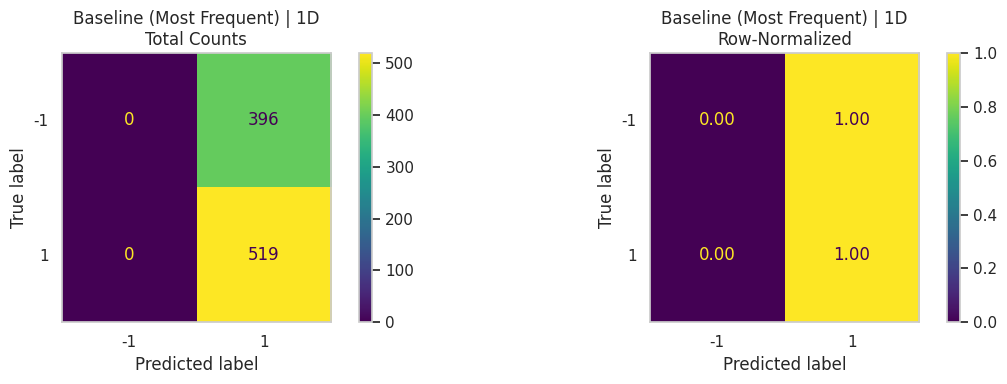

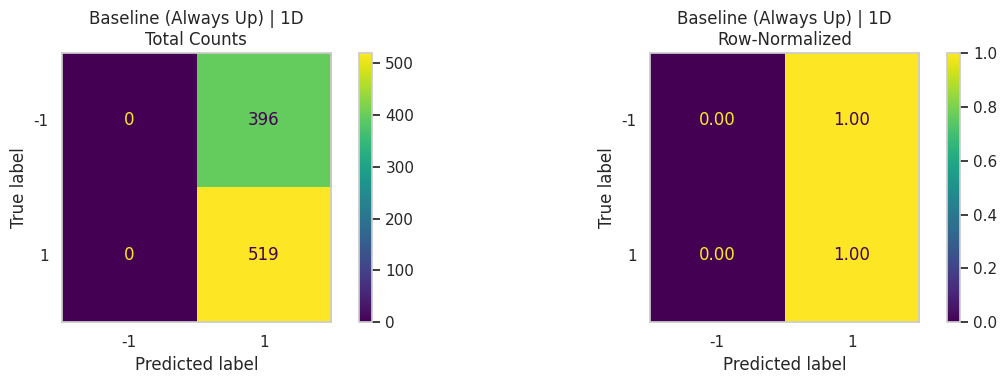

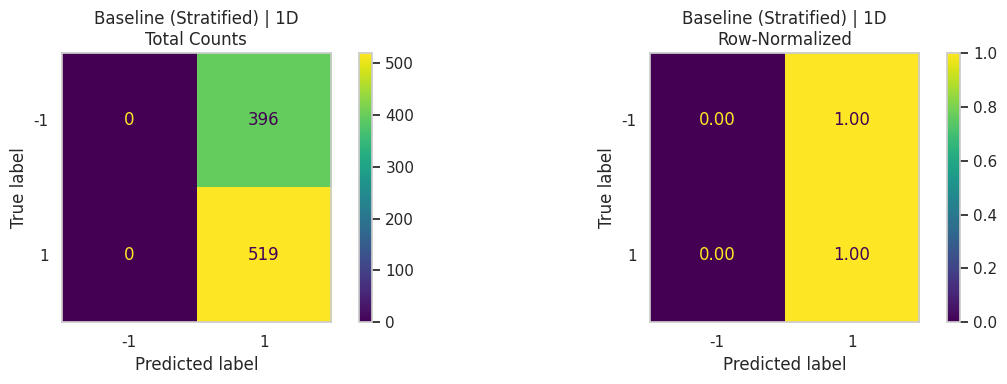

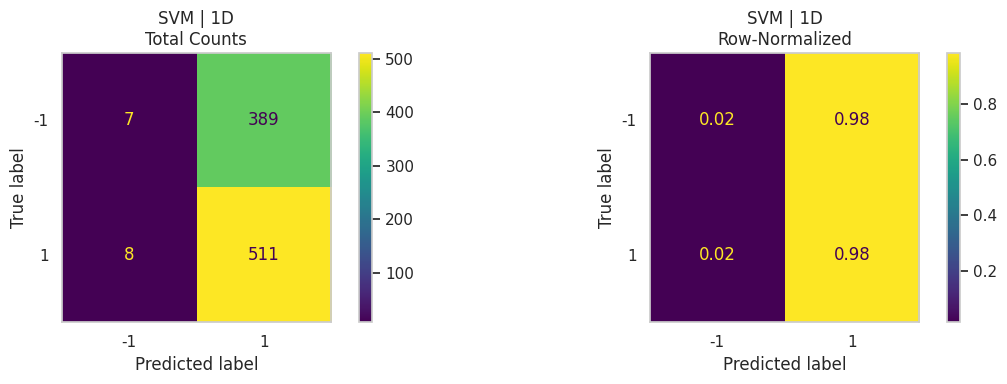

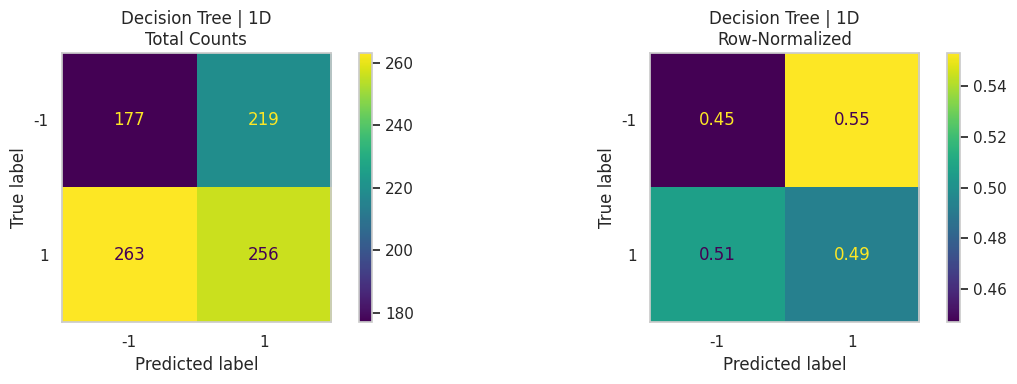

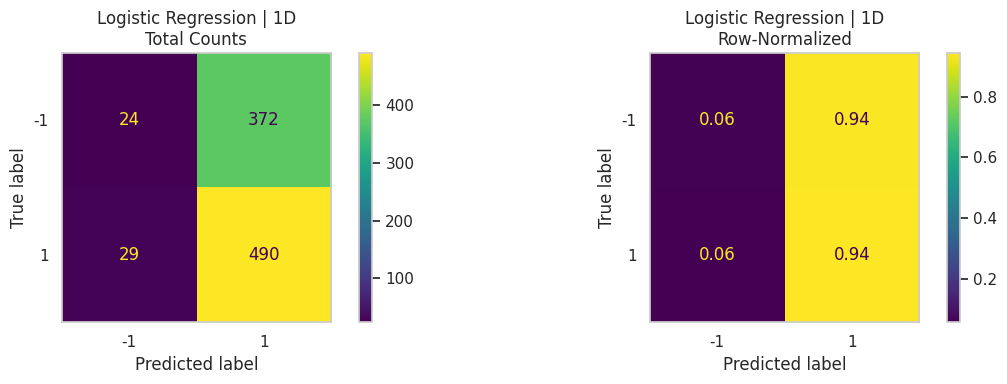

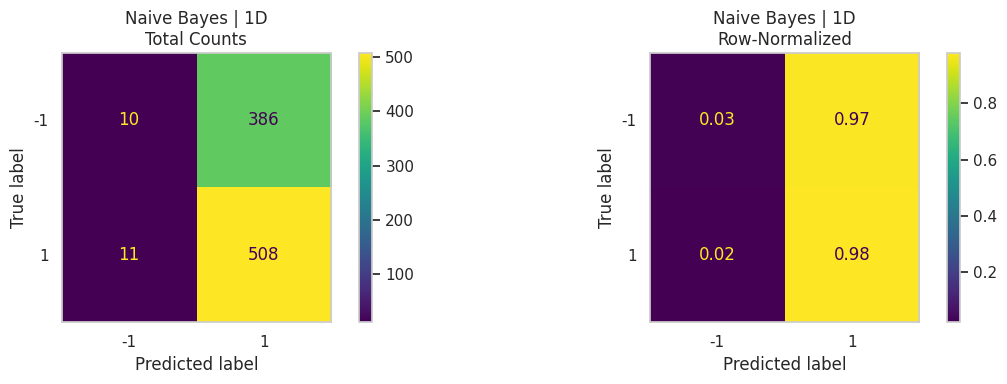

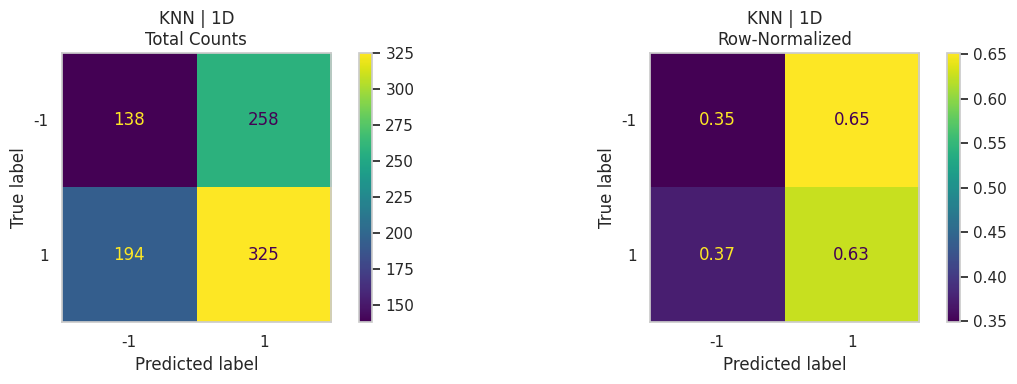

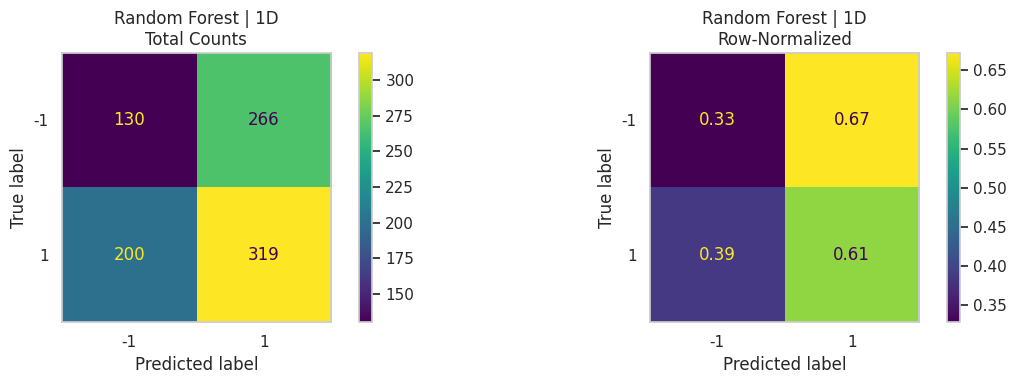

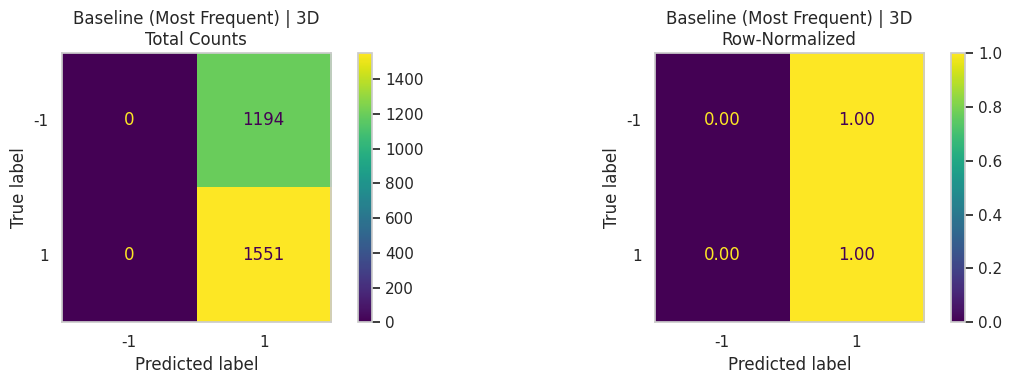

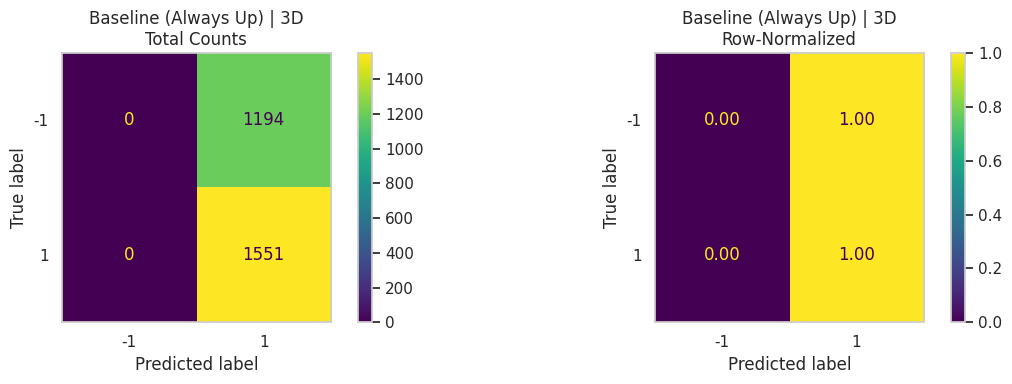

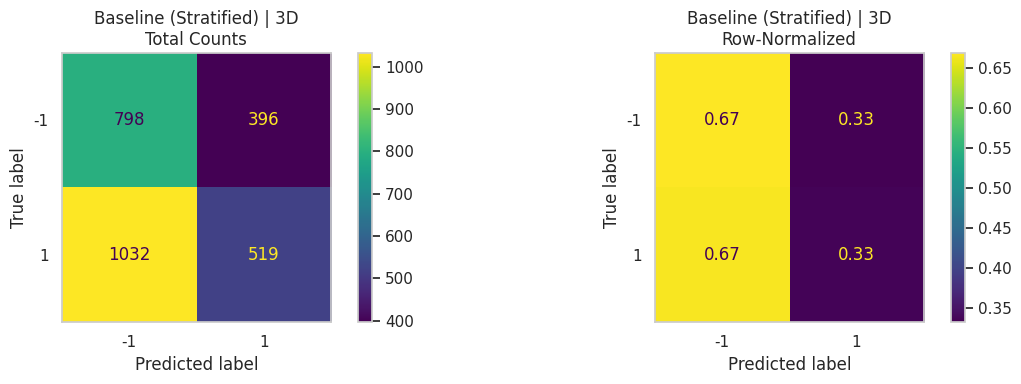

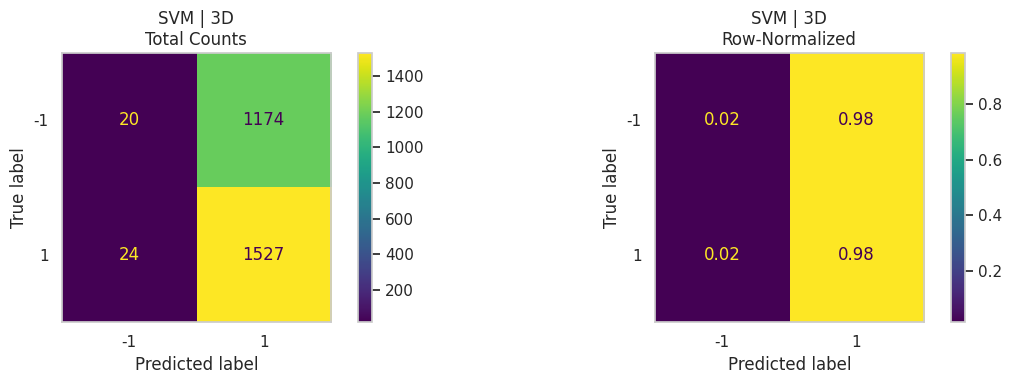

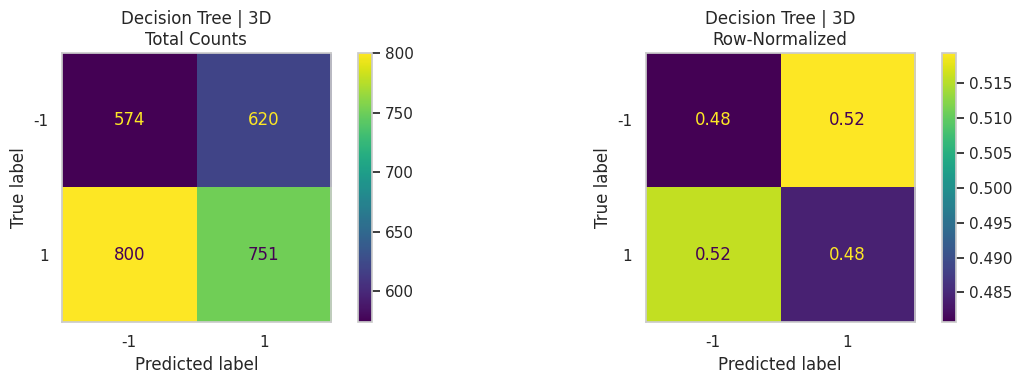

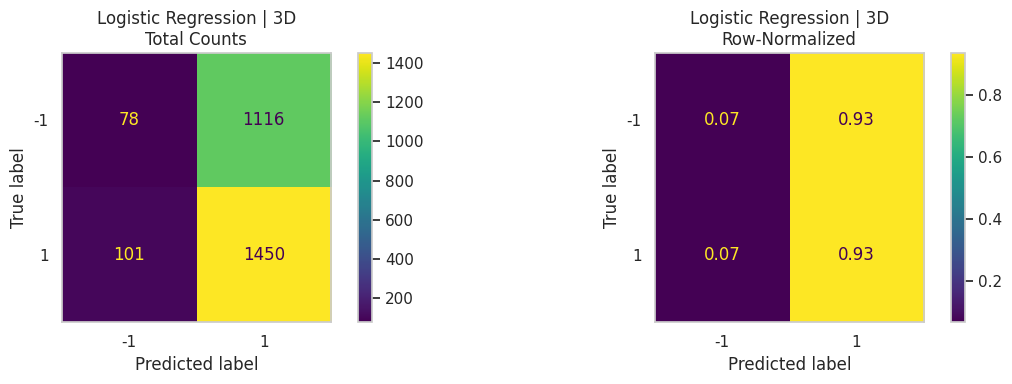

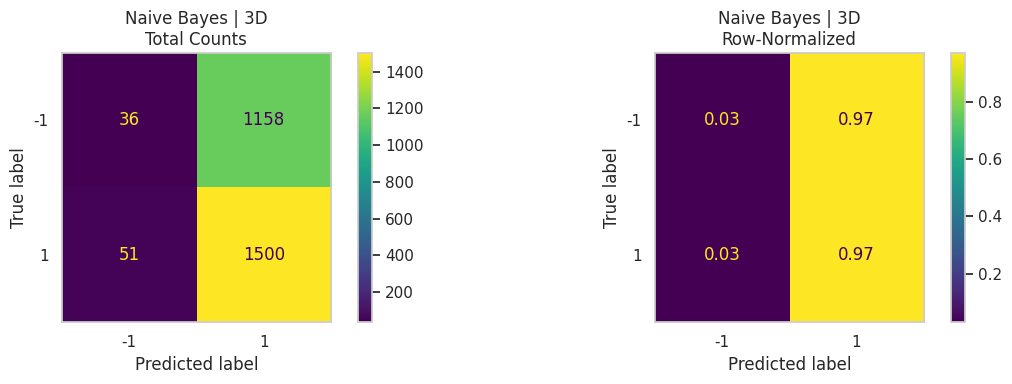

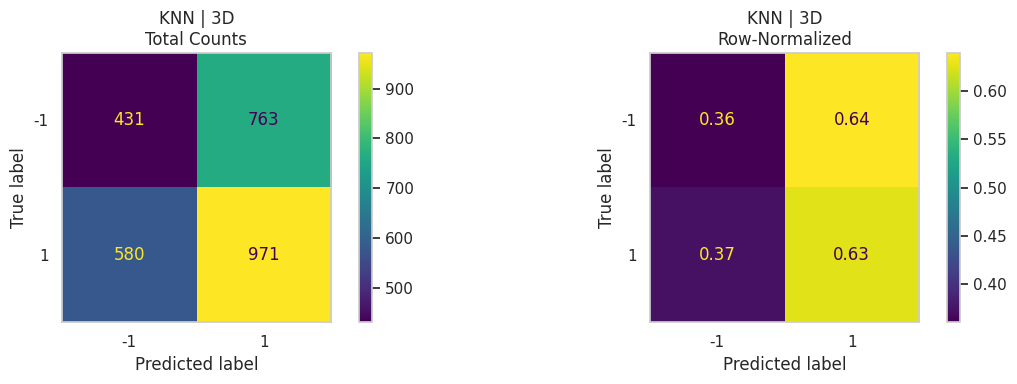

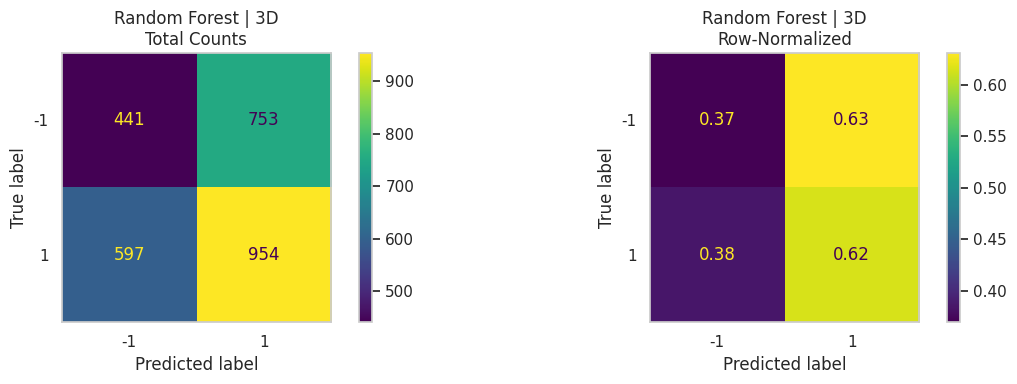

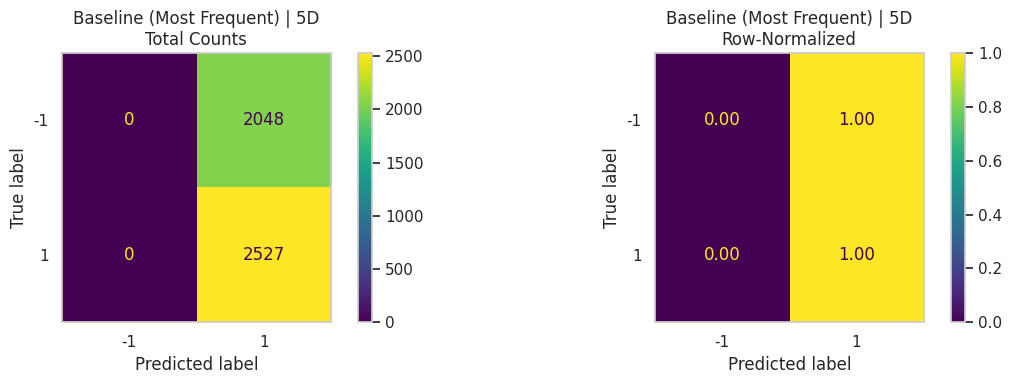

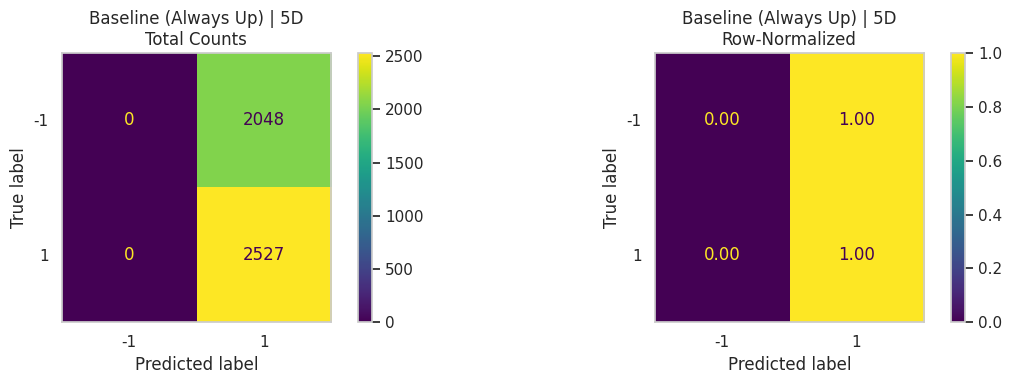

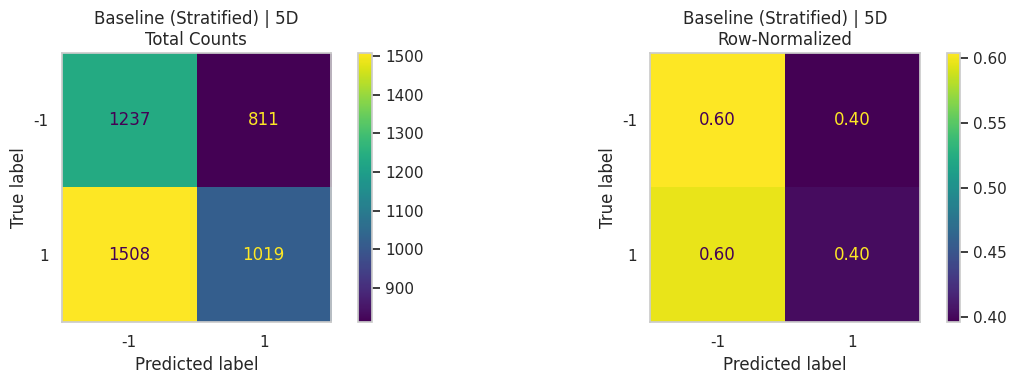

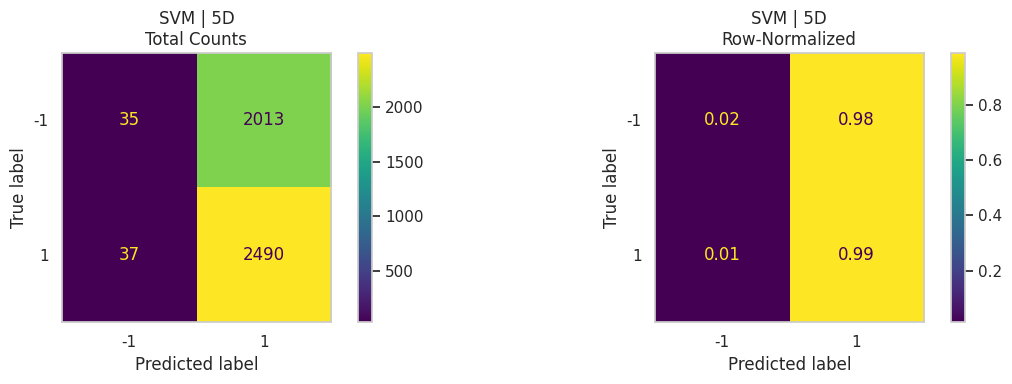

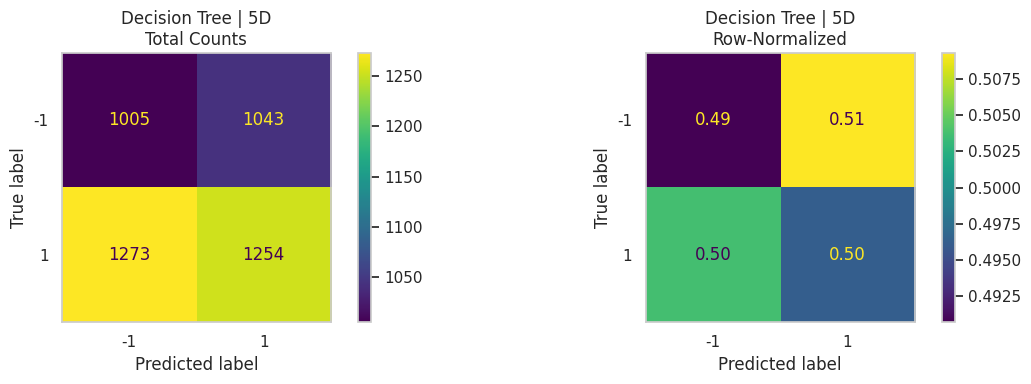

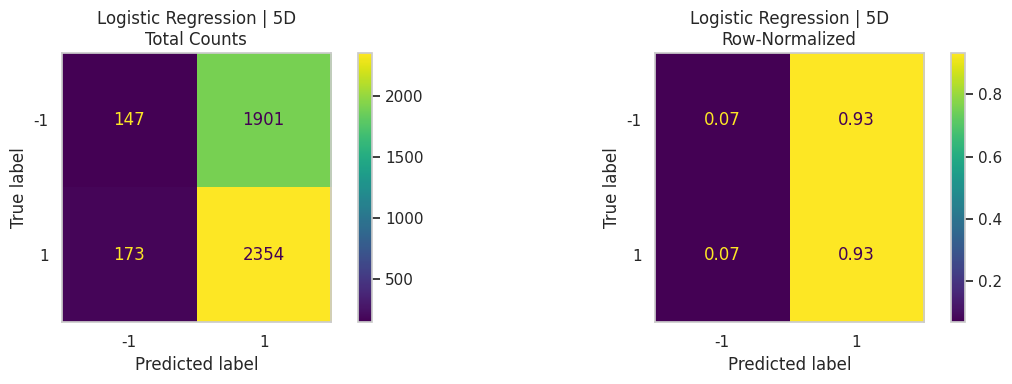

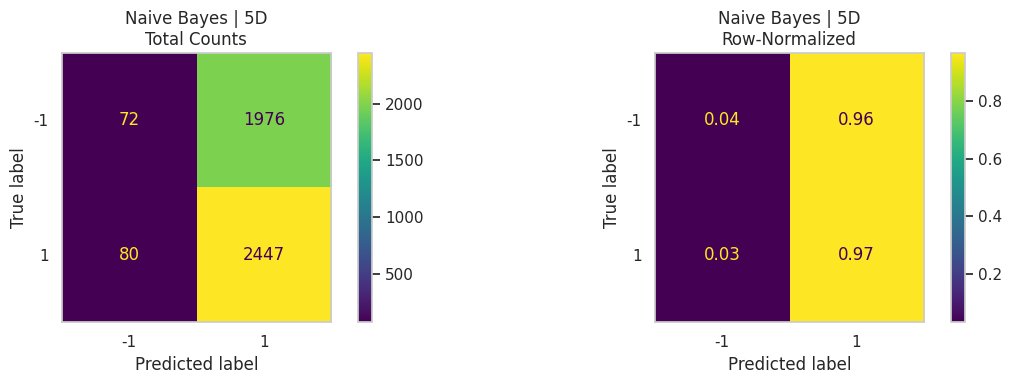

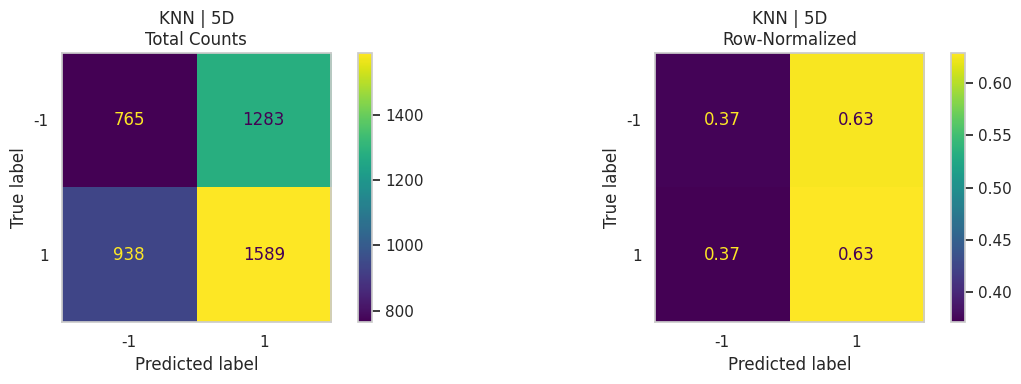

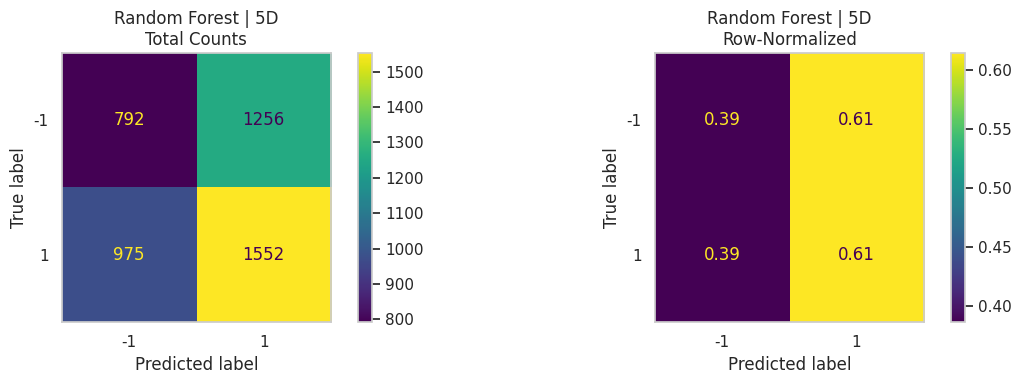

In [14]:
for window_label in WINDOW_SPECS.keys():
    for model_name in MODEL_CONFIGS.keys():
        records = window_metric_stores[window_label][model_name]

        if len(records) == 0:
            continue

        cm_total = np.sum([np.array(r['Confusion Matrix']) for r in records], axis=0)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Raw counts
        disp1 = ConfusionMatrixDisplay(
            confusion_matrix=cm_total,
            display_labels=[-1, 1]
        )
        disp1.plot(
            ax=axes[0],
            colorbar=True,
            values_format='d',
            im_kw={'interpolation': 'nearest'}
        )
        axes[0].grid(False)
        axes[0].set_title(f"{model_name} | {window_label}\nTotal Counts")

        # Row-normalized
        row_sums = cm_total.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm_total, row_sums, where=row_sums != 0)

        disp2 = ConfusionMatrixDisplay(
            confusion_matrix=cm_norm,
            display_labels=[-1, 1]
        )
        disp2.plot(
            ax=axes[1],
            colorbar=True,
            values_format='.2f',
            im_kw={'interpolation': 'nearest'}
        )
        axes[1].grid(False)
        axes[1].set_title(f"{model_name} | {window_label}\nRow-Normalized")

        plt.tight_layout()
        plt.show()

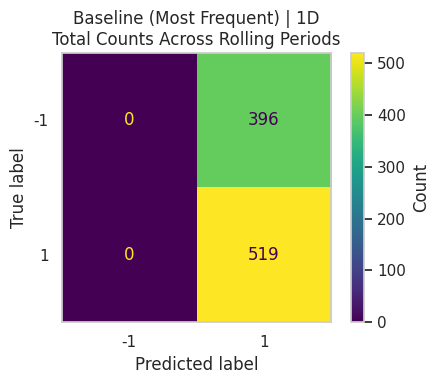

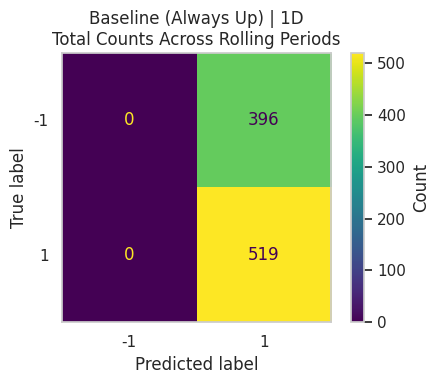

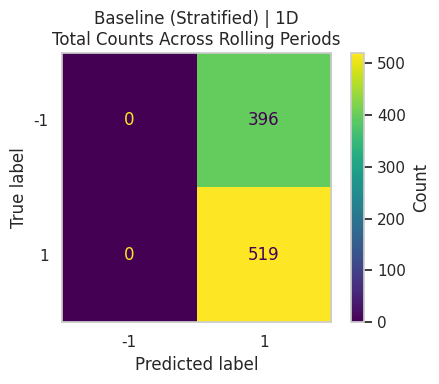

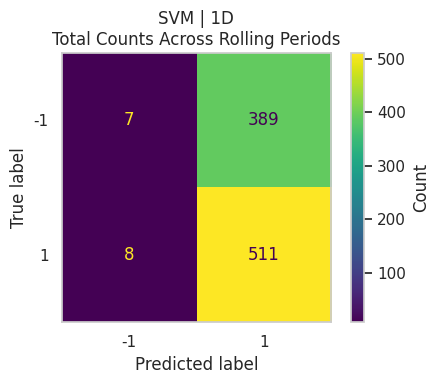

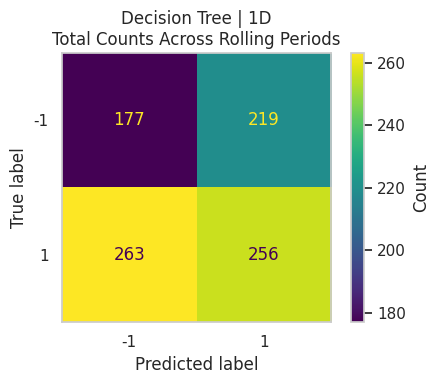

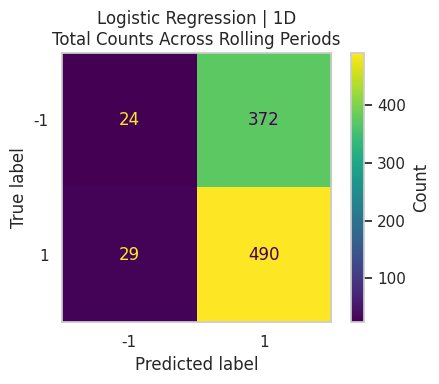

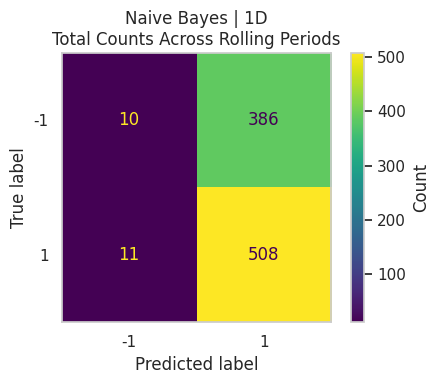

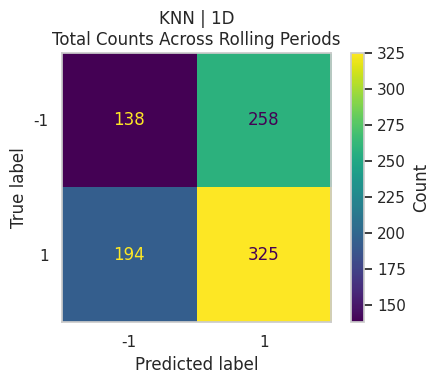

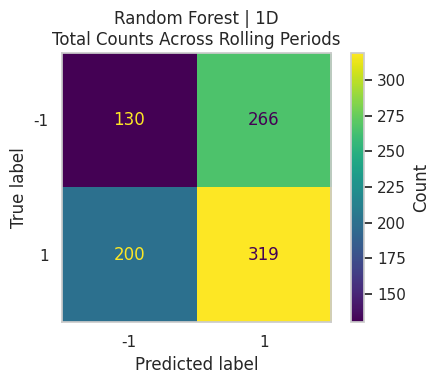

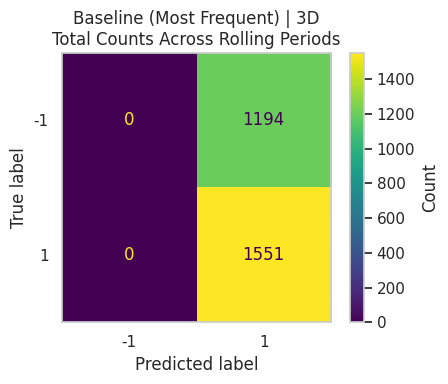

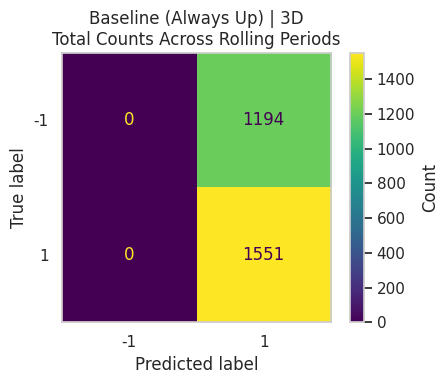

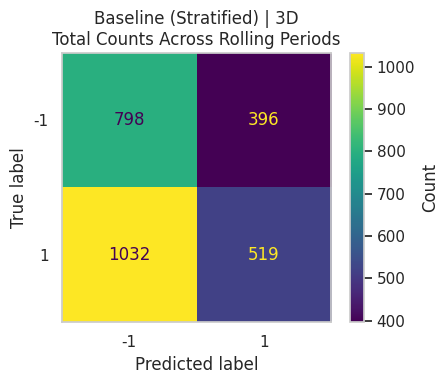

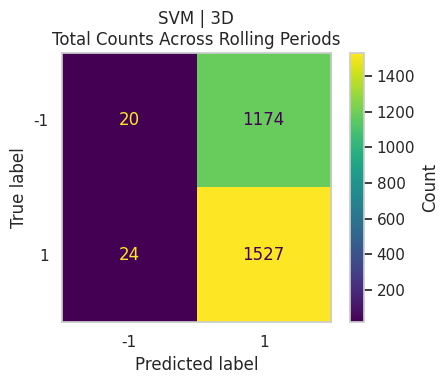

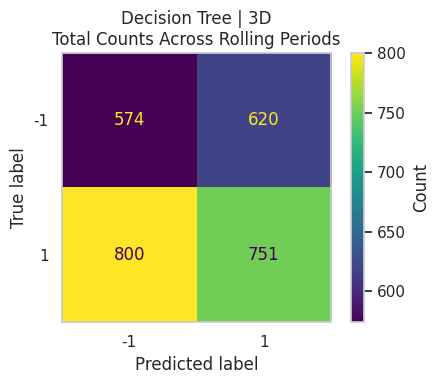

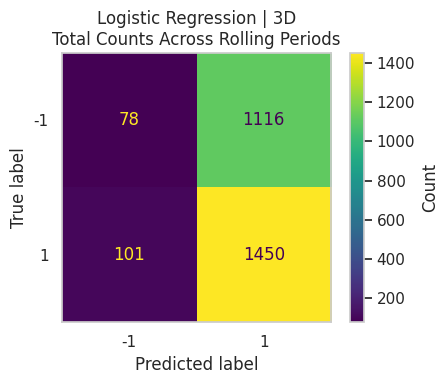

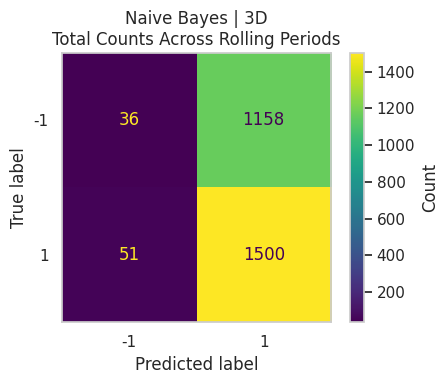

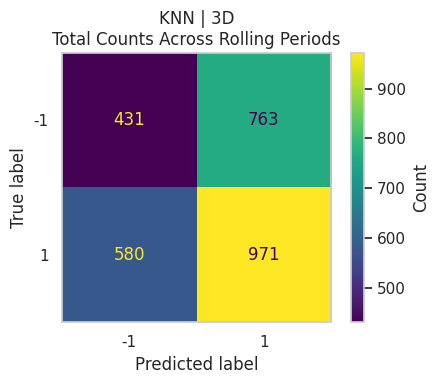

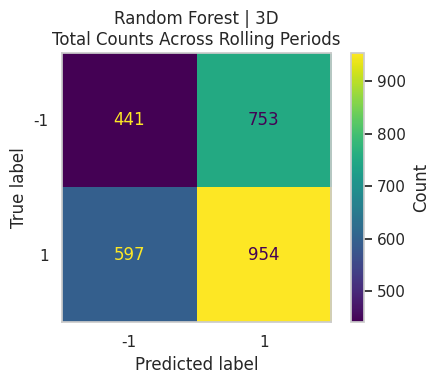

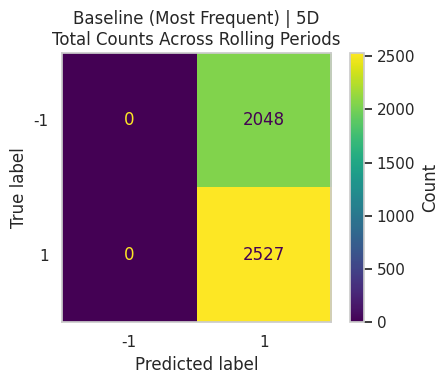

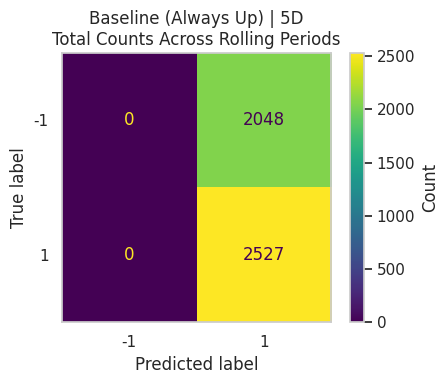

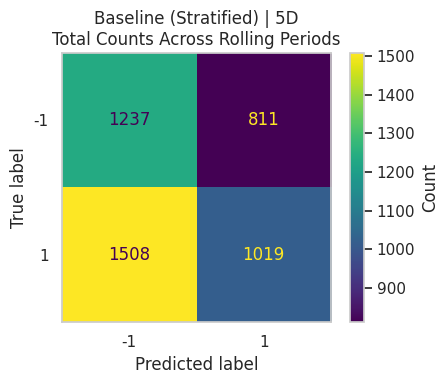

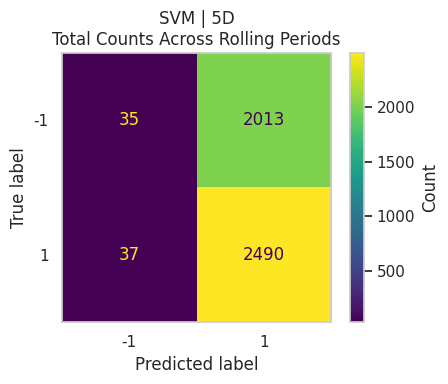

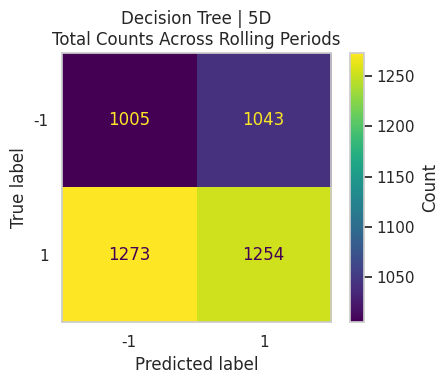

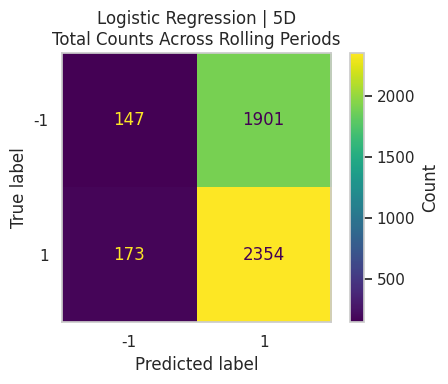

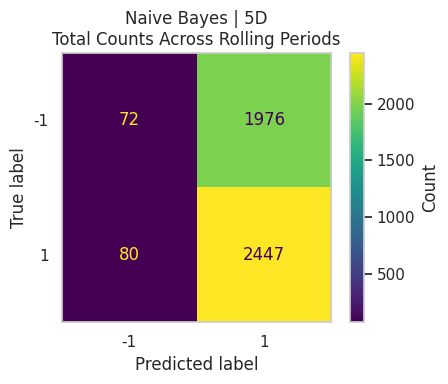

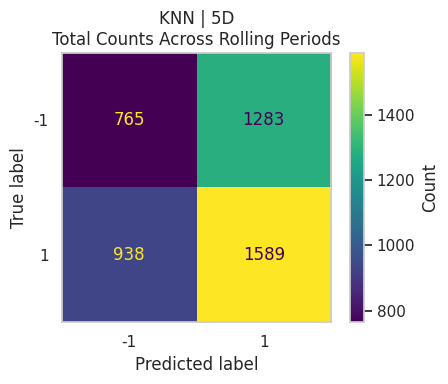

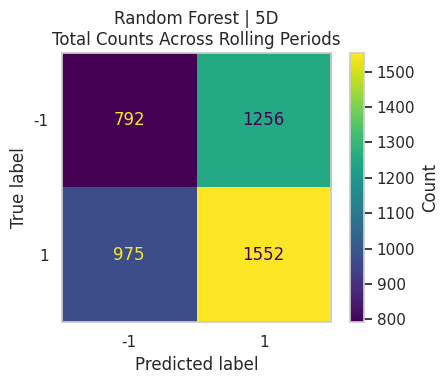

In [15]:
for window_label in WINDOW_SPECS.keys():
    for model_name in MODEL_CONFIGS.keys():
        records = window_metric_stores[window_label][model_name]

        if len(records) == 0:
            continue

        cm_total = np.sum([np.array(r['Confusion Matrix']) for r in records], axis=0)

        fig, ax = plt.subplots(figsize=(5, 4))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm_total,
            display_labels=[-1, 1]
        )
        disp.plot(ax=ax, colorbar=True, values_format='d')
        ax.grid(False)
        ax.set_title(f"{model_name} | {window_label}\nTotal Counts Across Rolling Periods")
        disp.im_.colorbar.ax.set_ylabel("Count", rotation=90)

        plt.tight_layout()
        plt.show()

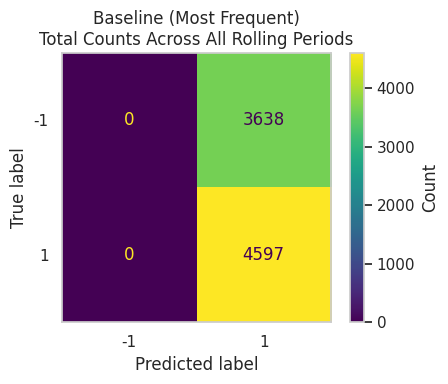

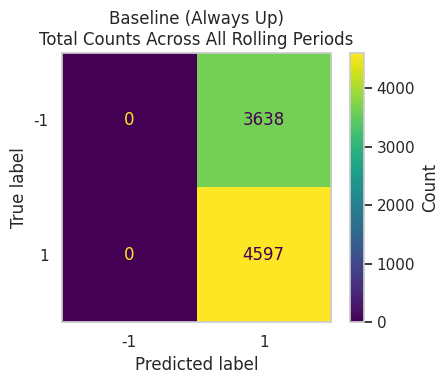

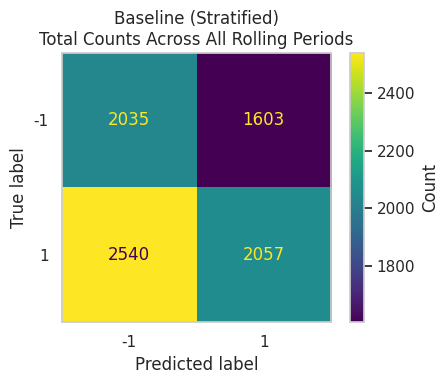

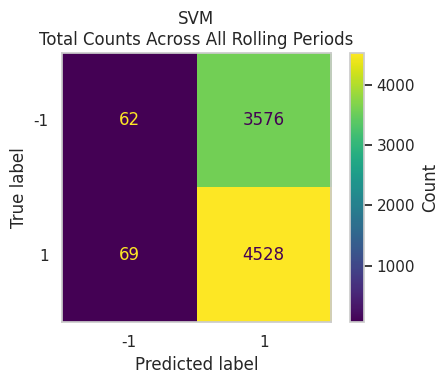

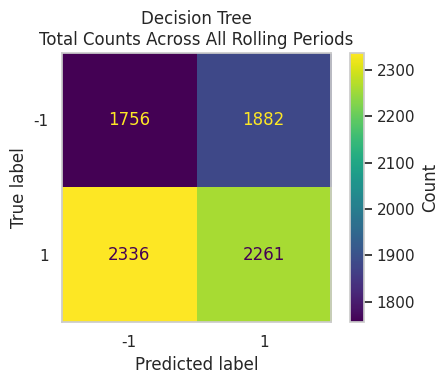

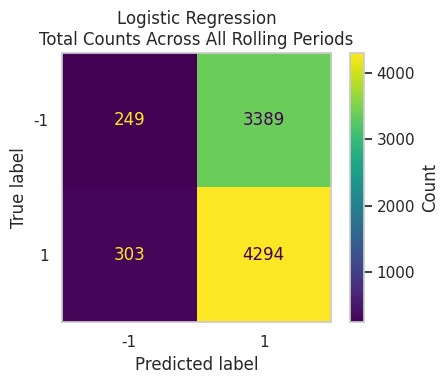

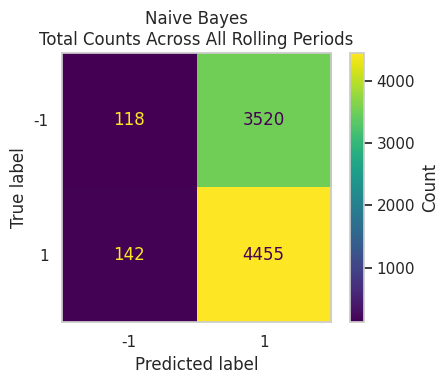

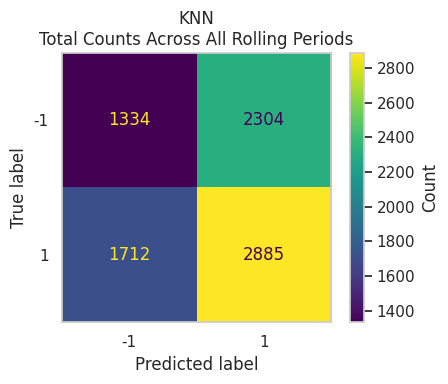

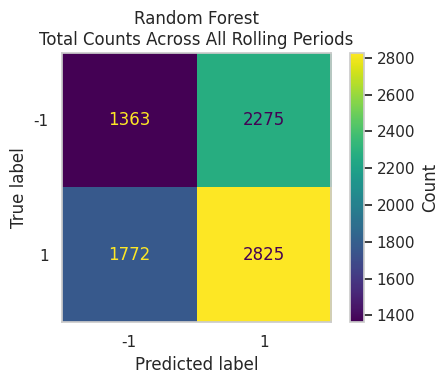

In [16]:
for model_name in MODEL_CONFIGS.keys():
    model_records = [
        row for row in rolling_metric_rows
        if row['Model'] == model_name
    ]

    if len(model_records) == 0:
        continue

    cm_total = np.sum([np.array(r['Confusion Matrix']) for r in model_records], axis=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_total,
        display_labels=[-1, 1]
    )
    disp.plot(ax=ax, colorbar=True, values_format='d')
    ax.grid(False)
    ax.set_title(f"{model_name}\nTotal Counts Across All Rolling Periods")
    disp.im_.colorbar.ax.set_ylabel("Count", rotation=90)

    plt.tight_layout()
    plt.show()

#### Step 11: Optional legacy sections
The main notebook path above is intentionally limited to the SPY-only daily classifier comparison. Threshold sweeps, constrained-threshold logic, strategy-return reporting, extra baselines, deeper models, and the VIX extension are kept out of the main path.


In [17]:
RUN_OPTIONAL_VIX_EXTENSION = False
RUN_OPTIONAL_STRATEGY_ANALYSIS = False
RUN_LEGACY_EXPERIMENTS = False



def build_optional_vix_scenario():
    vix_df = pd.read_csv('VIX_1995_to_2025_feature_expansion_v5.csv')
    vix_df.columns = vix_df.columns.str.strip()
    vix_df['Date'] = pd.to_datetime(vix_df['Date'], errors='coerce')
    vix_df = vix_df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

    vix_feature_cols_raw = [c for c in vix_df.columns if c != 'Date']
    vix_df = vix_df.rename(columns={c: f'vx_{c}' for c in vix_feature_cols_raw})
    vix_feature_cols = [f'vx_{c}' for c in vix_feature_cols_raw]

    df_with_vix = df.merge(vix_df, on='Date', how='left')
    return build_scenario(df_with_vix, FEATURE_COLS + vix_feature_cols, 'SPY + VIX')


if RUN_OPTIONAL_VIX_EXTENSION:
    optional_vix_scenario = build_optional_vix_scenario()
    print('Optional VIX extension ready with the same split logic.')
    print('Optional VIX feature count:', len(optional_vix_scenario['feature_cols']))
else:
    optional_vix_scenario = None
    print('Optional VIX extension is disabled in the main notebook path.')

print('Optional strategy analysis enabled:', RUN_OPTIONAL_STRATEGY_ANALYSIS)
print('Legacy experiments enabled:', RUN_LEGACY_EXPERIMENTS)


Optional VIX extension is disabled in the main notebook path.
Optional strategy analysis enabled: False
Legacy experiments enabled: False
